# Good Pot Bad Crop Evaluation

This notebook reviews the `good_pot_bad_crop` study from MLflow runs and
produces both the compact paper-facing figures and the fuller appendix
diagnostics used to sanity-check the conclusions.

## Study Scope

We compare annotator-selection strategies on three datasets:
- `letter26` and `trec6` with simulated annotators
- `dopanim` with real annotator labels

The two headline metrics are:
- `test_acc`: downstream classifier performance on the test split
- `acc_pair_micro`: correctness of the selected `(sample, annotator)`
  label pairs

## Analysis Flow

The notebook proceeds in five stages:
1. configure repository-relative paths, plotting styles, and experiment constants
2. load MLflow runs and reconstruct tidy analysis columns from raw params and tags
3. fetch per-cycle metric histories and summarize them with normalized AULC
4. pick one representative strategy per dataset and classifier for the main view
5. generate appendix diagnostics that expose the full assigner sweep

## Execution Notes

Run the notebook in a Python environment that contains the repository
dependencies, for example one created from `environment.yml` or
`environment.dev.yml`.

Path resolution is intentionally environment-agnostic:
- the repository root is inferred automatically from the current working directory
- `DALC_RESULTS_ROOT` or `DALCE_RESULTS_ROOT` can redirect the MLflow results location
- exported figures are written next to the notebook by default


In [1]:
from __future__ import annotations

import itertools
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from mlflow.entities import ViewType
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# Resolve repository-relative paths whether the notebook is launched
# from the project root or from the notebooks directory.
NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "configs").exists() else NOTEBOOK_DIR.parent
OUTPUT_DIR = NOTEBOOK_DIR

# Central study configuration used throughout the notebook.
USE_CASE_NAME = "good_pot_bad_crop"
EXPERIMENT_NAME = "good_pot_bad_crop"
METRICS = ["test_acc", "acc_pair_micro"]
ONLY_FINISHED = True
DEDUPLICATE_LATEST_PER_SEED = True
DATASET_ORDER = ["letter26", "trec6", "dopanim"]
MAIN_CLASSIFIERS = ["annot_mix_gating", "crowd_em", "majority_voting"]
APPENDIX_CLASSIFIERS = ["annot_mix_gating", "crowd_em", "majority_voting"]
ASSIGNER_ORDER = [
    "quota_sample",
    "greedy_sample",
    "epsilon_greedy_sample[eps=0.05]",
    "epsilon_greedy_sample[eps=0.1]",
    "epsilon_greedy_sample[cosine:0.2->0.01,T=10]",
]
DELTA_BASELINE_CLASSIFIER = "majority_voting"
DELTA_BASELINE_ASSIGNER = "quota_sample"

# Optional slicing hooks for targeted debugging without changing the
# downstream analysis code.
RUN_FILTERS = {
    "dataset": [],
    "seed": [],
    "classifier_variant": APPENDIX_CLASSIFIERS,
    "scorer_variant": [],
    "assigner_variant": [],
    "strategy": [],
}
STRATEGY_CONTAINS = []
FILTER_ONLY_FINISHED = ONLY_FINISHED

# Shared visual encoding keeps the same classifier or assigner visually
# consistent across all figures.
CLASSIFIER_COLORS = {
    "annot_mix": "#008080",
    "annot_mix_gating": "#008080",
    "crowd_em": "#c83737",
    "majority_voting": "#222222",
}
CLASSIFIER_LINESTYLES = {
    "annot_mix": "-",
    "annot_mix_gating": "-",
    "crowd_em": "--",
    "majority_voting": ":",
}
CLASSIFIER_MARKERS = {
    "annot_mix": "o",
    "annot_mix_gating": "o",
    "crowd_em": "s",
    "majority_voting": "D",
}
ASSIGNER_COLORS = {
    "quota_sample": "#666666",
    "greedy_sample": "#1b9e77",
    "epsilon_greedy_sample[eps=0.05]": "#d95f02",
    "epsilon_greedy_sample[eps=0.1]": "#7570b3",
    "epsilon_greedy_sample[cosine:0.2->0.01,T=10]": "#e7298a",
}

# Prefer an explicit results override when runs live outside the repo.
results_root = os.environ.get("DALC_RESULTS_ROOT") or os.environ.get("DALCE_RESULTS_ROOT")
RESULTS_PATH = Path(results_root).expanduser() / "mlflow" if results_root else REPO_ROOT / "mlflow"
MANIFEST_PATH = REPO_ROOT / "manifests" / f"{USE_CASE_NAME}.jsonl"
USE_CASE_PATH = REPO_ROOT / "configs" / "launch" / "use_cases" / f"{USE_CASE_NAME}.json"

results_source_label = (
    "environment override via `DALC_RESULTS_ROOT` / `DALCE_RESULTS_ROOT`"
    if results_root
    else "repository-local `mlflow/` directory"
)
summary_lines = [
    "**Notebook configuration**",
    "",
    f"- use case: `{USE_CASE_NAME}`",
    f"- experiment: `{EXPERIMENT_NAME}`",
    f"- metrics: `{', '.join(METRICS)}`",
    f"- datasets: `{', '.join(DATASET_ORDER)}`",
    f"- results source: {results_source_label}",
    "- figure output: notebook directory",
    f"- main classifiers: `{', '.join(MAIN_CLASSIFIERS)}`",
    f"- delta baseline: `{DELTA_BASELINE_CLASSIFIER} + {DELTA_BASELINE_ASSIGNER}`",
]
display(Markdown(chr(10).join(summary_lines)))


**Notebook configuration**

- use case: `good_pot_bad_crop`
- experiment: `good_pot_bad_crop`
- metrics: `test_acc, acc_pair_micro`
- datasets: `letter26, trec6, dopanim`
- results source: repository-local `mlflow/` directory
- figure output: notebook directory
- main classifiers: `annot_mix_gating, crowd_em, majority_voting`
- delta baseline: `majority_voting + quota_sample`

## Helper Functions: Tracking And Run Enrichment

This block turns raw MLflow state into a tidy experiment table.

In particular, it:
- configures the SQLite tracking URI from either a directory or a direct database path
- loads the manifest and use-case metadata that define the expected seed grid
- flattens MLflow params, metrics, and tags into one row per run
- derives readable `dataset`, `classifier_variant`, `assigner_variant`, and `strategy` columns
- optionally filters and deduplicates reruns so later summaries operate on one run per seed


In [2]:
def configure_tracking(results_path: Path) -> MlflowClient:
    # Accept either a directory that contains `mlruns.db` or a direct
    # path to the SQLite database itself.
    results_path = Path(results_path).expanduser().resolve()
    db_path = results_path if results_path.suffix.lower() == ".db" else results_path / "mlruns.db"
    tracking_uri = f"sqlite:///{db_path.as_posix()}"
    mlflow.set_tracking_uri(tracking_uri)
    return MlflowClient(tracking_uri=tracking_uri)


def find_experiment(client: MlflowClient, experiment_name: str):
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        raise ValueError(f"MLflow experiment {experiment_name!r} not found.")
    return exp


def search_runs_all(client: MlflowClient, experiment_id: str):
    return client.search_runs(
        [experiment_id],
        run_view_type=ViewType.ALL,
        max_results=50000,
        order_by=["attributes.start_time DESC"],
    )


def runs_to_frame(runs) -> pd.DataFrame:
    rows = []
    for run in runs:
        # Flatten params, metrics, and tags into one analysis row.
        row = {
            "run_id": run.info.run_id,
            "status": run.info.status,
            "artifact_uri": run.info.artifact_uri,
            "start_time": pd.to_datetime(run.info.start_time, unit="ms", utc=True),
            "end_time": pd.to_datetime(run.info.end_time, unit="ms", utc=True) if run.info.end_time else pd.NaT,
        }
        for k, v in run.data.params.items():
            row[f"param/{k}"] = v
        for k, v in run.data.metrics.items():
            row[f"metric/{k}"] = v
        for k, v in run.data.tags.items():
            row[f"tag/{k}"] = v
        rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("start_time", ascending=False).reset_index(drop=True)
    return df


def count_manifest_rows(path: Path) -> int | None:
    path = Path(path)
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as fh:
        return sum(1 for _ in fh)


def load_use_case(path: Path) -> dict | None:
    path = Path(path)
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def extract_expected_seed_values(use_case: dict | None) -> list[int] | None:
    if not use_case:
        return None
    for axis in use_case.get("axes", []):
        if axis.get("name") == "seed":
            values = axis.get("values")
            if values is None:
                return None
            return [int(v) for v in values]
    return None


def first_present(row: pd.Series, keys, default=None):
    for key in keys:
        if key in row.index and pd.notna(row[key]):
            return row[key]
    return default


def fmt_num(value, digits=3):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "?"
    try:
        f = float(value)
    except Exception:
        return str(value)
    if f.is_integer():
        return str(int(f))
    return f"{f:.{digits}g}"


def derive_classifier_variant(row: pd.Series) -> str:
    return str(first_present(row, ["param/choice/classifier"], default="unknown"))


def derive_scorer_variant(row: pd.Series) -> str:
    return str(first_present(row, ["param/choice/scorer_scorer.actual"], default="unknown"))


def derive_assigner_variant(row: pd.Series) -> str:
    choice = first_present(row, ["param/choice/assigner_assigner.actual"], default="unknown")
    if choice == "epsilon_greedy_sample":
        # Reconstruct the fully specified epsilon schedule so different
        # scheduler settings do not collapse into the same label.
        eps_min = first_present(row, ["param/assigner/actual/epsilon_min"])
        eps_max = first_present(row, ["param/assigner/actual/epsilon_max"])
        eps_T = first_present(row, ["param/assigner/actual/epsilon_T"])
        eps_schedule = first_present(row, ["param/assigner/actual/epsilon_schedule"], default="cosine")
        try:
            eps_min_f = float(eps_min) if eps_min is not None else None
            eps_max_f = float(eps_max) if eps_max is not None else None
        except Exception:
            eps_min_f = None
            eps_max_f = None
        if eps_min_f is not None and eps_max_f is not None and math.isclose(eps_min_f, eps_max_f):
            return f"epsilon_greedy_sample[eps={fmt_num(eps_min_f)}]"
        return (
            f"epsilon_greedy_sample[{eps_schedule}:{fmt_num(eps_max)}->"
            f"{fmt_num(eps_min)},T={fmt_num(eps_T)}]"
        )
    return str(choice)


def enrich_runs(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    out["dataset"] = out.apply(lambda row: first_present(row, ["param/choice/dataset"], default="unknown"), axis=1)
    out["seed"] = pd.to_numeric(out.get("param/seed"), errors="coerce")
    out["classifier_variant"] = out.apply(derive_classifier_variant, axis=1)
    out["scorer_variant"] = out.apply(derive_scorer_variant, axis=1)
    out["assigner_variant"] = out.apply(derive_assigner_variant, axis=1)
    out["strategy"] = out.apply(
        lambda row: f"{row['classifier_variant']} | {row['scorer_variant']} + {row['assigner_variant']}",
        axis=1,
    )
    return out


def apply_run_filters(
    runs_df: pd.DataFrame,
    *,
    filters: dict[str, list] | None = None,
    strategy_contains: list[str] | None = None,
    only_finished: bool | None = None,
) -> pd.DataFrame:
    df = runs_df.copy()
    if only_finished is True and "status" in df.columns:
        df = df[df["status"] == "FINISHED"]
    if only_finished is False and "status" in df.columns:
        df = df[df["status"] != "FINISHED"]

    filters = filters or {}
    for col, values in filters.items():
        if values is None:
            continue
        values = [v for v in values if v is not None and v != ""]
        if not values:
            continue
        if col not in df.columns:
            raise KeyError(f"Unknown filter column: {col}")
        df = df[df[col].isin(values)]

    if strategy_contains:
        mask = pd.Series(True, index=df.index)
        for token in strategy_contains:
            if token:
                mask &= df["strategy"].str.contains(token, case=False, regex=False, na=False)
        df = df[mask]

    return df.reset_index(drop=True)


def summarize_seed_values(seed_series: pd.Series) -> tuple[int, tuple[int, ...]]:
    seeds = pd.Series(seed_series).dropna()
    if seeds.empty:
        return 0, tuple()
    values = tuple(sorted({int(v) for v in seeds.astype(int).tolist()}))
    return len(values), values


def summarize_run_coverage(
    runs_df: pd.DataFrame,
    *,
    group_cols: list[str] | tuple[str, ...] = ("dataset", "strategy"),
) -> pd.DataFrame:
    if runs_df.empty:
        return pd.DataFrame(columns=[*group_cols, "n_runs", "n_seeds", "seeds", "duplicate_runs"])

    rows = []
    for keys, group in runs_df.groupby(list(group_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        n_seeds, seeds = summarize_seed_values(group["seed"])
        row = dict(zip(group_cols, keys))
        row["n_runs"] = int(group["run_id"].nunique())
        row["n_seeds"] = int(n_seeds)
        row["seeds"] = seeds
        row["duplicate_runs"] = int(row["n_runs"] - row["n_seeds"])
        rows.append(row)

    return pd.DataFrame(rows).sort_values(list(group_cols)).reset_index(drop=True)


def select_latest_seed_runs(
    runs_df: pd.DataFrame,
    *,
    subset_cols: list[str] | tuple[str, ...] = ("dataset", "strategy", "seed"),
) -> pd.DataFrame:
    if runs_df.empty:
        return runs_df.copy()

    # Keep the most recent rerun for each dataset/strategy/seed cell.
    order_cols = [col for col in ["end_time", "start_time"] if col in runs_df.columns]
    df = runs_df.sort_values(order_cols + ["run_id"], ascending=[False] * (len(order_cols) + 1)).copy()
    df = df.drop_duplicates(list(subset_cols), keep="first")
    return df.sort_values("start_time", ascending=False).reset_index(drop=True)


def assigner_sort_key(assigner_variant: str) -> int:
    try:
        return ASSIGNER_ORDER.index(assigner_variant)
    except ValueError:
        return len(ASSIGNER_ORDER)


## Helper Functions: Metric Summaries And Strategy Selection

This block moves from raw per-step histories to compact summary tables.

It covers three related transformations:
- fetch metric trajectories for each retained MLflow run
- convert each trajectory into a normalized area-under-the-learning-curve (AULC) value
- aggregate those per-run summaries across seeds and pick one representative strategy per classifier

The representative strategy is chosen independently for each
`dataset x classifier x metric` slice.


In [3]:
def standard_error(values: pd.Series | np.ndarray) -> float:
    series = pd.Series(values).dropna()
    n = int(series.shape[0])
    if n <= 1:
        return np.nan
    return float(series.std(ddof=1) / np.sqrt(n))


def load_metric_history_table(
    client: MlflowClient,
    runs_df: pd.DataFrame,
    metric_name: str,
    *,
    only_finished: bool = True,
) -> pd.DataFrame:
    rows = []
    subset = runs_df
    if only_finished:
        subset = subset[subset["status"] == "FINISHED"]

    # Fetch the full per-cycle metric trajectory for every retained run.
    for _, run in subset.iterrows():
        history = client.get_metric_history(run["run_id"], metric_name)
        for item in history:
            rows.append(
                {
                    "run_id": run["run_id"],
                    "dataset": run["dataset"],
                    "seed": run["seed"],
                    "strategy": run["strategy"],
                    "classifier_variant": run["classifier_variant"],
                    "scorer_variant": run["scorer_variant"],
                    "assigner_variant": run["assigner_variant"],
                    "metric": metric_name,
                    "step": int(item.step),
                    "value": float(item.value),
                }
            )
    hist_df = pd.DataFrame(rows)
    if not hist_df.empty:
        hist_df = hist_df.sort_values(["dataset", "classifier_variant", "assigner_variant", "seed", "step"]).reset_index(drop=True)
    return hist_df


def normalized_aulc(step_values: pd.DataFrame) -> float:
    curve = step_values[["step", "value"]].dropna().sort_values("step")
    if curve.empty:
        return np.nan
    if curve.shape[0] == 1:
        return float(curve["value"].iloc[0])
    span = float(curve["step"].iloc[-1] - curve["step"].iloc[0])
    area = float(np.trapezoid(curve["value"].to_numpy(), curve["step"].to_numpy()))
    # Divide by the covered step range so curves of different lengths
    # remain directly comparable.
    return area / span if span > 0 else float(curve["value"].iloc[-1])


def compute_aulc_per_run(history_df: pd.DataFrame) -> pd.DataFrame:
    if history_df.empty:
        return pd.DataFrame(
            columns=[
                "run_id", "dataset", "seed", "strategy", "classifier_variant",
                "scorer_variant", "assigner_variant", "metric", "aulc",
                "max_step", "n_points",
            ]
        )

    rows = []
    group_cols = [
        "run_id",
        "dataset",
        "seed",
        "strategy",
        "classifier_variant",
        "scorer_variant",
        "assigner_variant",
        "metric",
    ]
    for keys, group in history_df.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys))
        row["aulc"] = normalized_aulc(group)
        row["max_step"] = float(group["step"].max())
        row["n_points"] = int(group.shape[0])
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_aulc(aulc_df: pd.DataFrame) -> pd.DataFrame:
    if aulc_df.empty:
        return pd.DataFrame(
            columns=[
                "dataset", "classifier_variant", "assigner_variant", "strategy",
                "metric", "aulc_mean", "aulc_se", "n_runs", "n_seeds", "seeds",
            ]
        )

    rows = []
    group_cols = ["dataset", "classifier_variant", "assigner_variant", "strategy", "metric"]
    for keys, group in aulc_df.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys))
        n_seeds, seeds = summarize_seed_values(group["seed"])
        row["aulc_mean"] = float(group["aulc"].mean())
        row["aulc_se"] = standard_error(group["aulc"])
        row["n_runs"] = int(group["run_id"].nunique())
        row["n_seeds"] = int(n_seeds)
        row["seeds"] = seeds
        rows.append(row)

    out = pd.DataFrame(rows)
    return out.sort_values(
        ["dataset", "classifier_variant", "aulc_mean", "assigner_variant"],
        ascending=[True, True, False, True],
    ).reset_index(drop=True)


def compute_curve_summary(history_df: pd.DataFrame) -> pd.DataFrame:
    if history_df.empty:
        return pd.DataFrame(columns=["dataset", "strategy", "classifier_variant", "assigner_variant", "step", "mean_value", "se_value", "n"])
    return (
        history_df.groupby(["dataset", "strategy", "classifier_variant", "assigner_variant", "step"], as_index=False)
        .agg(mean_value=("value", "mean"), se_value=("value", standard_error), n=("value", "count"))
    )


def select_main_strategies(
    aulc_summary_df: pd.DataFrame,
    *,
    classifiers: list[str],
    dataset_order: list[str],
) -> pd.DataFrame:
    if aulc_summary_df.empty:
        return pd.DataFrame(columns=["dataset", "classifier_variant", "assigner_variant", "strategy", "metric", "aulc_mean", "aulc_se"])

    rows = []
    for dataset in dataset_order:
        ds_df = aulc_summary_df[aulc_summary_df["dataset"] == dataset]
        for classifier in classifiers:
            clf_df = ds_df[ds_df["classifier_variant"] == classifier].copy()
            if clf_df.empty:
                continue
            clf_df["_assigner_order"] = clf_df["assigner_variant"].map(assigner_sort_key)
            # Keep the nominal best strategy by AULC, but preserve the
            # existing second-best rule for `crowd_em` so the notebook
            # reproduces the study's current presentation choice.
            idx = 1 if classifier == "crowd_em" else 0
            chosen = clf_df.sort_values(["aulc_mean", "_assigner_order"], ascending=[False, True]).iloc[idx]
            rows.append(chosen.drop(labels=["_assigner_order"]))
    return pd.DataFrame(rows).reset_index(drop=True)


def format_main_selection_table(selected_df: pd.DataFrame) -> pd.DataFrame:
    if selected_df.empty:
        return selected_df.copy()
    out = selected_df[["dataset", "classifier_variant", "assigner_variant", "aulc_mean", "aulc_se"]].copy()
    out = out.rename(columns={"classifier_variant": "classifier", "assigner_variant": "selected_assigner"})
    return out.sort_values(["dataset", "classifier"]).reset_index(drop=True)


## Helper Functions: Plotting And Appendix Diagnostics

This section contains the visual layer of the notebook.

The plotting functions are separated by audience:
- the main-paper figures show one selected strategy per classifier and dataset
- the appendix figures restore the full assigner sweep and pairwise comparisons

Keeping the plotting code isolated makes it easier to reuse the same
summarized tables in different presentation layouts without changing the
data-processing logic above.


In [4]:
from matplotlib.ticker import FuncFormatter


def metric_label(metric_name: str) -> str:
    return {
        "test_acc": "Test Accuracy",
        "acc_pair_micro": "Pair Accuracy (micro)",
    }.get(metric_name, metric_name)


def make_main_legend_label(classifier_variant: str, assigner_variant: str) -> str:
    if classifier_variant == "majority_voting":
        return "majority_voting"
    return f"{classifier_variant} ({assigner_variant})"


def summarize_delta_aulc(
    aulc_df: pd.DataFrame,
    *,
    metric_name: str,
    baseline_classifier: str,
    baseline_assigner: str,
    classifiers: list[str],
) -> pd.DataFrame:
    summary_cols = [
        "dataset",
        "classifier_variant",
        "assigner_variant",
        "strategy",
        "metric",
        "delta_mean",
        "delta_se",
        "baseline_aulc_mean",
        "baseline_aulc_se",
        "baseline_classifier",
        "baseline_assigner",
        "n_pairs",
        "n_seeds",
        "seeds",
    ]
    subset = aulc_df[
        (aulc_df["metric"] == metric_name)
        & (aulc_df["classifier_variant"].isin(classifiers))
    ].copy()
    if subset.empty:
        return pd.DataFrame(columns=summary_cols)

    # Pair each strategy with the baseline at the same dataset and seed.
    baseline_df = (
        subset[
            (subset["classifier_variant"] == baseline_classifier)
            & (subset["assigner_variant"] == baseline_assigner)
        ][["dataset", "seed", "metric", "aulc"]]
        .rename(columns={"aulc": "baseline_aulc"})
        .drop_duplicates()
    )
    merged = subset.merge(
        baseline_df,
        on=["dataset", "seed", "metric"],
        how="left",
        validate="many_to_one",
    )
    merged = merged[merged["baseline_aulc"].notna()].copy()
    merged["delta_aulc"] = merged["aulc"] - merged["baseline_aulc"]
    baseline_stats = (
        baseline_df.groupby(["dataset", "metric"], as_index=False)
        .agg(
            baseline_aulc_mean=("baseline_aulc", "mean"),
            baseline_aulc_se=("baseline_aulc", standard_error),
        )
    )

    rows = []
    group_cols = ["dataset", "classifier_variant", "assigner_variant", "strategy", "metric"]
    for keys, group in merged.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys))
        n_seeds, seeds = summarize_seed_values(group["seed"])
        row["delta_mean"] = float(group["delta_aulc"].mean())
        row["delta_se"] = standard_error(group["delta_aulc"])
        baseline_match = baseline_stats[
            (baseline_stats["dataset"] == row["dataset"])
            & (baseline_stats["metric"] == row["metric"])
        ]
        if baseline_match.empty:
            row["baseline_aulc_mean"] = np.nan
            row["baseline_aulc_se"] = np.nan
        else:
            row["baseline_aulc_mean"] = float(baseline_match["baseline_aulc_mean"].iloc[0])
            row["baseline_aulc_se"] = float(baseline_match["baseline_aulc_se"].iloc[0])
        row["baseline_classifier"] = baseline_classifier
        row["baseline_assigner"] = baseline_assigner
        row["n_pairs"] = int(group.shape[0])
        row["n_seeds"] = int(n_seeds)
        row["seeds"] = seeds
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=summary_cols)

    out = pd.DataFrame(rows)
    out["_classifier_order"] = out["classifier_variant"].apply(
        lambda value: classifiers.index(value) if value in classifiers else len(classifiers)
    )
    out["_assigner_order"] = out["assigner_variant"].map(assigner_sort_key)
    return out.sort_values(
        ["dataset", "_classifier_order", "_assigner_order", "strategy"],
        ascending=[True, True, True, True],
    ).drop(columns=["_classifier_order", "_assigner_order"]).reset_index(drop=True)


def plot_main_learning_curve_panel(
    curve_df: pd.DataFrame,
    selected_df: pd.DataFrame,
    *,
    dataset: str,
    metric_name: str,
):
    plot_rows = selected_df[selected_df["dataset"] == dataset].copy()
    if plot_rows.empty:
        return None

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for classifier in MAIN_CLASSIFIERS:
        row_df = plot_rows[plot_rows["classifier_variant"] == classifier]
        if row_df.empty:
            continue
        row = row_df.iloc[0]
        strategy_df = curve_df[(curve_df["dataset"] == dataset) & (curve_df["strategy"] == row["strategy"])].sort_values("step")
        if strategy_df.empty:
            continue
        label = make_main_legend_label(row["classifier_variant"], row["assigner_variant"])
        color = CLASSIFIER_COLORS.get(row["classifier_variant"], "#333333")
        linestyle = CLASSIFIER_LINESTYLES.get(row["classifier_variant"], "-")
        err = strategy_df["se_value"].fillna(0.0)
        ax.plot(strategy_df["step"], strategy_df["mean_value"], label=label, color=color, linestyle=linestyle, linewidth=2.2)
        ax.fill_between(strategy_df["step"], strategy_df["mean_value"] - err, strategy_df["mean_value"] + err, color=color, alpha=0.14)

    ax.set_title(f"{dataset} | {metric_label(metric_name)}")
    ax.set_xlabel("Labeled pair budget (MLflow step)")
    ax.set_ylabel(metric_label(metric_name))
    ax.legend(loc="best", frameon=True)
    fig.tight_layout()
    return fig


def plot_delta_aulc_dotplot(
    delta_summary_df: pd.DataFrame,
    *,
    metric_name: str,
    classifiers: list[str],
    dataset_order: list[str],
    baseline_classifier: str,
    baseline_assigner: str,
):
    subset = delta_summary_df[
        (delta_summary_df["metric"] == metric_name)
        & (delta_summary_df["classifier_variant"].isin(classifiers))
    ].copy()
    if subset.empty:
        return None

    subset["_classifier_order"] = subset["classifier_variant"].apply(
        lambda value: classifiers.index(value) if value in classifiers else len(classifiers)
    )
    subset["_assigner_order"] = subset["assigner_variant"].map(assigner_sort_key)
    subset["row_label"] = subset.apply(
        lambda row: (
            f"{row['classifier_variant']} | {row['assigner_variant']} (baseline)"
            if (
                row["classifier_variant"] == baseline_classifier
                and row["assigner_variant"] == baseline_assigner
            )
            else f"{row['classifier_variant']} | {row['assigner_variant']}"
        ),
        axis=1,
    )

    row_order = (
        subset[["classifier_variant", "assigner_variant", "row_label", "_classifier_order", "_assigner_order"]]
        .drop_duplicates()
        .sort_values(["_classifier_order", "_assigner_order", "row_label"])
        .reset_index(drop=True)
    )
    row_order["y"] = np.arange(len(row_order), dtype=float)
    subset = subset.merge(
        row_order[["classifier_variant", "assigner_variant", "y"]],
        on=["classifier_variant", "assigner_variant"],
        how="left",
    )

    datasets = [dataset for dataset in dataset_order if dataset in subset["dataset"].unique()]
    if not datasets:
        return None

    fig_width = max(11.0, 4.2 * len(datasets))
    fig_height = max(4.0, 0.2 * len(row_order) + 1.2)
    fig, axes = plt.subplots(1, len(datasets), figsize=(fig_width, fig_height), sharey=True)
    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        ds_df = subset[subset["dataset"] == dataset].copy()
        x_values = ds_df["delta_mean"].dropna().to_numpy()
        x_limit = 0.05 if x_values.size == 0 else max(0.01, float(np.nanmax(np.abs(x_values))) * 1.25)
        ax.axvline(0.0, color="#888888", linestyle="--", linewidth=1.1, zorder=1)
        for row in row_order.itertuples(index=False):
            point_df = ds_df[
                (ds_df["classifier_variant"] == row.classifier_variant)
                & (ds_df["assigner_variant"] == row.assigner_variant)
            ]
            if point_df.empty:
                continue
            point = point_df.iloc[0]
            color = CLASSIFIER_COLORS.get(point["classifier_variant"], "#333333")
            marker = CLASSIFIER_MARKERS.get(point["classifier_variant"], "o")
            xerr = None if pd.isna(point["delta_se"]) else point["delta_se"]
            ax.errorbar(
                point["delta_mean"],
                point["y"],
                xerr=xerr,
                fmt=marker,
                color=color,
                ecolor=color,
                elinewidth=1.5,
                capsize=3,
                markersize=6,
                zorder=3,
            )
        baseline_panel_df = ds_df[
            (ds_df["classifier_variant"] == baseline_classifier)
            & (ds_df["assigner_variant"] == baseline_assigner)
        ]
        baseline_note = None
        if not baseline_panel_df.empty:
            baseline_value = float(baseline_panel_df["baseline_aulc_mean"].iloc[0])
            baseline_note = f"baseline AULC = {100.0 * baseline_value:.1f} pp"
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{100.0 * x:.1f}"))
        ax.set_title(dataset)
        ax.set_xlabel(
            f"Δ normalized AULC (pp) vs {baseline_classifier} + {baseline_assigner}"
        )
        ax.set_xlim(-x_limit, x_limit)
        ax.grid(axis="x", alpha=0.25, linewidth=0.8)
        if baseline_note is not None:
            ax.text(
                0.02,
                0.02,
                baseline_note,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=9,
                bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
            )

    axes[0].set_yticks(row_order["y"])
    axes[0].set_yticklabels(row_order["row_label"])
    axes[0].set_ylabel("classifier | assigner")
    axes[0].invert_yaxis()
    for ax in axes[1:]:
        ax.tick_params(axis="y", labelleft=False)

    legend_classifiers = []
    for classifier in classifiers:
        if classifier not in subset["classifier_variant"].unique():
            continue
        legend_classifiers.append(
            plt.Line2D(
                [0],
                [0],
                marker=CLASSIFIER_MARKERS.get(classifier, "o"),
                color=CLASSIFIER_COLORS.get(classifier, "#333333"),
                linestyle="",
                markersize=6,
                label=classifier,
            )
        )
    if legend_classifiers:
        fig.legend(legend_classifiers, [handle.get_label() for handle in legend_classifiers], loc="center left", bbox_to_anchor=(1.01, 0.5), title="classifier")

    fig.suptitle(
        f"{metric_label(metric_name)}: paired ΔAULC vs {baseline_classifier} + {baseline_assigner}",
        y=1.02,
    )
    fig.tight_layout()
    return fig


def plot_aulc_heatmap(
    aulc_summary_df: pd.DataFrame,
    *,
    metric_name: str,
    classifiers: list[str],
    dataset_order: list[str],
):
    subset = aulc_summary_df[aulc_summary_df["metric"] == metric_name].copy()
    if subset.empty:
        return None

    row_labels = []
    mean_values = []
    se_values = []
    for dataset in dataset_order:
        ds_df = subset[subset["dataset"] == dataset]
        for classifier in classifiers:
            clf_df = ds_df[ds_df["classifier_variant"] == classifier]
            row_labels.append(f"{dataset} | {classifier}")
            mean_row = []
            se_row = []
            for assigner in ASSIGNER_ORDER:
                match = clf_df[clf_df["assigner_variant"] == assigner]
                if match.empty:
                    mean_row.append(np.nan)
                    se_row.append(np.nan)
                else:
                    mean_row.append(float(match["aulc_mean"].iloc[0]))
                    se_row.append(float(match["aulc_se"].iloc[0]))
            mean_values.append(mean_row)
            se_values.append(se_row)

    mean_data = np.array(mean_values, dtype=float)
    se_data = np.array(se_values, dtype=float)
    masked = np.ma.masked_invalid(mean_data)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="#f0f0f0")

    fig_height = max(4.5, 0.50 * len(row_labels) + 1.8)
    fig, ax = plt.subplots(figsize=(11.2, fig_height))
    im = ax.imshow(masked, aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(len(ASSIGNER_ORDER)))
    ax.set_xticklabels(ASSIGNER_ORDER, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_title(f"{metric_label(metric_name)} AULC summary")

    # Switch text color at the global mean so annotations remain legible.
    mean_threshold = np.nanmean(mean_data)
    for i in range(mean_data.shape[0]):
        for j in range(mean_data.shape[1]):
            if np.isnan(mean_data[i, j]):
                continue
            mean_value = mean_data[i, j]
            se_value = se_data[i, j]
            text_color = "white" if mean_value > mean_threshold else "black"
            label = f"{mean_value:.3f}\n± {se_value:.3f}" if not np.isnan(se_value) else f"{mean_value:.3f}"
            ax.text(j, i, label, ha="center", va="center", color=text_color, fontsize=7.5, linespacing=1.15)

    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="mean normalized AULC")
    fig.tight_layout()
    return fig


def plot_appendix_learning_curves(
    curve_df: pd.DataFrame,
    *,
    classifier_variant: str,
    metric_name: str,
    dataset_order: list[str],
):
    subset = curve_df[(curve_df["classifier_variant"] == classifier_variant)].copy()
    if subset.empty:
        return None

    datasets = [dataset for dataset in dataset_order if dataset in subset["dataset"].unique()]
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 4.6), sharey=False)
    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        ds_df = subset[subset["dataset"] == dataset].copy()
        strategy_order = (
            ds_df[["strategy", "assigner_variant"]]
            .drop_duplicates()
            .assign(_assigner_order=lambda frame: frame["assigner_variant"].map(assigner_sort_key))
            .sort_values(["_assigner_order", "strategy"])
        )
        for row in strategy_order.itertuples(index=False):
            group = ds_df[ds_df["strategy"] == row.strategy].sort_values("step")
            color = ASSIGNER_COLORS.get(row.assigner_variant, "#333333")
            err = group["se_value"].fillna(0.0)
            ax.plot(group["step"], group["mean_value"], label=row.assigner_variant, color=color, linewidth=2.0)
            ax.fill_between(group["step"], group["mean_value"] - err, group["mean_value"] + err, color=color, alpha=0.12)
        ax.set_title(dataset)
        ax.set_xlabel("Labeled pair budget (MLflow step)")
        ax.set_ylabel(metric_label(metric_name))

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), title="assigner")
    fig.suptitle(f"Appendix: {classifier_variant} on {metric_label(metric_name)}", y=1.02)
    fig.tight_layout()
    return fig


def pairwise_win_rates(history_df: pd.DataFrame, *, strategies=None) -> pd.DataFrame:
    output_cols = [
        "strategy_a", "strategy_b", "n_cells", "win_rate_a",
        "tie_rate", "loss_rate_a", "mean_delta", "median_delta",
    ]
    df = history_df.copy()
    if strategies is not None:
        df = df[df["strategy"].isin(strategies)]
    if df.empty:
        return pd.DataFrame(columns=output_cols)

    # Compare strategies on the exact same dataset / seed / step cells.
    pivot = df.pivot_table(index=["dataset", "seed", "step"], columns="strategy", values="value")
    available = list(pivot.columns)
    if len(available) < 2:
        return pd.DataFrame(columns=output_cols)

    rows = []
    for a, b in itertools.permutations(available, 2):
        pair = pivot[[a, b]].dropna()
        if pair.empty:
            continue
        delta = pair[a] - pair[b]
        rows.append(
            {
                "strategy_a": a,
                "strategy_b": b,
                "n_cells": int(pair.shape[0]),
                "win_rate_a": float((delta > 0).mean()),
                "tie_rate": float((delta == 0).mean()),
                "loss_rate_a": float((delta < 0).mean()),
                "mean_delta": float(delta.mean()),
                "median_delta": float(delta.median()),
            }
        )
    if not rows:
        return pd.DataFrame(columns=output_cols)
    return pd.DataFrame(rows, columns=output_cols).sort_values(
        ["strategy_a", "win_rate_a", "mean_delta"],
        ascending=[True, False, False],
    )


def pairwise_win_matrix(pairwise_df: pd.DataFrame, value_col: str = "win_rate_a") -> pd.DataFrame:
    if pairwise_df.empty:
        return pd.DataFrame()
    matrix = pairwise_df.pivot(index="strategy_a", columns="strategy_b", values=value_col)
    for strategy in sorted(set(matrix.index).union(matrix.columns)):
        matrix.loc[strategy, strategy] = np.nan
    return matrix.sort_index().sort_index(axis=1)


## Load Experiment And Check Run Coverage

Before summarizing any metric, we verify that the stored MLflow runs match
the expected study structure.

This check answers three practical questions:
- did the manifest define the seed grid we think it did?
- how many runs were recorded per dataset and strategy?
- do we need to collapse duplicate reruns before aggregating across seeds?

The output tables here are intentionally diagnostic. If something looks
off in the final figures, this is usually the first section to inspect.


In [5]:
# Connect to MLflow and rebuild the run table used in the rest of the notebook.
client = configure_tracking(RESULTS_PATH)
experiment = find_experiment(client, EXPERIMENT_NAME)
runs = search_runs_all(client, experiment.experiment_id)
runs_df = enrich_runs(runs_to_frame(runs))
expected_rows = count_manifest_rows(MANIFEST_PATH)
use_case = load_use_case(USE_CASE_PATH)
expected_seed_values = extract_expected_seed_values(use_case)

print(f"Experiment ID         : {experiment.experiment_id}")
print(f"Experiment name       : {experiment.name}")
print(f"Expected manifest rows: {expected_rows}")
print(f"Observed MLflow runs  : {len(runs_df)}")
print(f"Configured seeds      : {expected_seed_values}")
print(f"Configured seed count : {len(expected_seed_values) if expected_seed_values is not None else '?'}")

status_overview = runs_df.groupby(["dataset", "status"]).size().rename("n_runs").reset_index()
display(status_overview.sort_values(["dataset", "status"]))

coverage_overview = summarize_run_coverage(runs_df)
display(coverage_overview.head(30))

print("Available datasets:", sorted(runs_df["dataset"].dropna().unique().tolist()))
print("Available classifier variants:")
for value in sorted(runs_df["classifier_variant"].dropna().unique().tolist()):
    print(" -", value)
print("Available assigner variants:", sorted(runs_df["assigner_variant"].dropna().unique().tolist()))

# Apply optional slicing hooks for debugging or focused analyses.
filtered_runs_raw_df = apply_run_filters(
    runs_df,
    filters=RUN_FILTERS,
    strategy_contains=STRATEGY_CONTAINS,
    only_finished=FILTER_ONLY_FINISHED,
)
print(f"Filtered raw runs: {len(filtered_runs_raw_df)} / {len(runs_df)}")
display(summarize_run_coverage(filtered_runs_raw_df).head(40))

if DEDUPLICATE_LATEST_PER_SEED:
    filtered_runs_df = select_latest_seed_runs(filtered_runs_raw_df)
    print(
        "Deduplicated to latest run per dataset/strategy/seed: "
        f"{len(filtered_runs_df)} / {len(filtered_runs_raw_df)}"
    )
else:
    filtered_runs_df = filtered_runs_raw_df.copy()

display(summarize_run_coverage(filtered_runs_df).head(40))
display(
    filtered_runs_df[[
        "run_id", "dataset", "seed", "status", "classifier_variant", "scorer_variant", "assigner_variant", "strategy"
    ]].head(20)
)


2026/03/31 23:06:15 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/31 23:06:15 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/31 23:06:15 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/31 23:06:15 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/31 23:06:15 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/31 23:06:15 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/31 23:06:15 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/31 23:06:15 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Experiment ID         : 1
Experiment name       : good_pot_bad_crop
Expected manifest rows: 990
Observed MLflow runs  : 1200
Configured seeds      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Configured seed count : 25


,dataset,status,n_runs
0,dopanim,FINISHED,400
1,letter26,FINISHED,400
2,trec6,FINISHED,400


,dataset,strategy,n_runs,n_seeds,seeds,duplicate_runs
0,dopanim,annot_mix | performance + epsilon_greedy_sampl...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
1,dopanim,annot_mix | performance + epsilon_greedy_sampl...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
2,dopanim,annot_mix | performance + epsilon_greedy_sampl...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
3,dopanim,annot_mix | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
4,dopanim,annot_mix | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
5,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
6,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
7,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
8,dopanim,annot_mix_gating | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
9,dopanim,annot_mix_gating | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0


Available datasets: ['dopanim', 'letter26', 'trec6']
Available classifier variants:
 - annot_mix
 - annot_mix_gating
 - crowd_em
 - majority_voting
Available assigner variants: ['epsilon_greedy_sample[cosine:0.2->0.01,T=10]', 'epsilon_greedy_sample[eps=0.05]', 'epsilon_greedy_sample[eps=0.1]', 'greedy_sample', 'quota_sample']
Filtered raw runs: 825 / 1200


,dataset,strategy,n_runs,n_seeds,seeds,duplicate_runs
0,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
1,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
2,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
3,dopanim,annot_mix_gating | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
4,dopanim,annot_mix_gating | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
5,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
6,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
7,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
8,dopanim,crowd_em | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
9,dopanim,crowd_em | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0


Deduplicated to latest run per dataset/strategy/seed: 825 / 825


,dataset,strategy,n_runs,n_seeds,seeds,duplicate_runs
0,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
1,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
2,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
3,dopanim,annot_mix_gating | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
4,dopanim,annot_mix_gating | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
5,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
6,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
7,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
8,dopanim,crowd_em | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
9,dopanim,crowd_em | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0


,run_id,dataset,seed,status,classifier_variant,scorer_variant,assigner_variant,strategy
0,52e9575a45484cefa7a1f7cdb41d9c33,trec6,20,FINISHED,annot_mix_gating,random,quota_sample,annot_mix_gating | random + quota_sample
1,2b397b57a3fa4cd799103cd19918dc5f,letter26,20,FINISHED,crowd_em,random,quota_sample,crowd_em | random + quota_sample
2,cde0c5b732f246479bf156f6b40e11af,trec6,22,FINISHED,crowd_em,random,quota_sample,crowd_em | random + quota_sample
3,6f6b08c4baf84b9f9ca40c9952872165,letter26,24,FINISHED,annot_mix_gating,performance,epsilon_greedy_sample[eps=0.05],annot_mix_gating | performance + epsilon_greed...
4,c28e1f47eabe49cc82bf20fb6816e8ff,trec6,24,FINISHED,annot_mix_gating,performance,greedy_sample,annot_mix_gating | performance + greedy_sample
5,0a2b93a7770147d5abfa1e7fa27edcc0,letter26,24,FINISHED,crowd_em,performance,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",crowd_em | performance + epsilon_greedy_sample...
6,2f7ad7924f02469da4abb538edf5ecdd,letter26,24,FINISHED,annot_mix_gating,performance,epsilon_greedy_sample[eps=0.1],annot_mix_gating | performance + epsilon_greed...
7,d07e30816daa4c7fa5af8a182a98f7d3,dopanim,22,FINISHED,annot_mix_gating,performance,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greed...
8,ecf466dd29254b0490d6503a77d9097b,trec6,24,FINISHED,annot_mix_gating,performance,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greed...
9,262011361f37436c9f5b95068ffafa14,dopanim,24,FINISHED,annot_mix_gating,performance,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greed...


## Main Paper View

This section creates the compact presentation layer used for the main
story of the study.

For each metric, the workflow is:
1. load the per-run learning-curve history from MLflow
2. summarize each run with normalized AULC
3. compare every strategy against the fixed `majority_voting + quota_sample` baseline
4. select one representative strategy per dataset and classifier
5. render both the paired `ΔAULC` comparison and the corresponding learning curves

The representative strategy is selected independently for each metric,
so the chosen assigner can differ between `test_acc` and
`acc_pair_micro`.


### Test Accuracy

Loaded 24750 metric-history rows for metric='test_acc' from 825 filtered runs.


,dataset,strategy,n_runs,n_seeds,seeds,duplicate_runs
0,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
1,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
2,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
3,dopanim,annot_mix_gating | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
4,dopanim,annot_mix_gating | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
5,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
6,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
7,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
8,dopanim,crowd_em | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
9,dopanim,crowd_em | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0


**Selected strategy per dataset and classifier**

,dataset,classifier,selected_assigner,aulc_mean,aulc_se
0,dopanim,annot_mix_gating,greedy_sample,0.704197,0.001662
1,dopanim,crowd_em,greedy_sample,0.670889,0.002758
2,dopanim,majority_voting,quota_sample,0.621839,0.002029
3,letter26,annot_mix_gating,greedy_sample,0.811241,0.001611
4,letter26,crowd_em,epsilon_greedy_sample[eps=0.05],0.616451,0.045147
5,letter26,majority_voting,quota_sample,0.762980,0.001160
6,trec6,annot_mix_gating,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.649663,0.004464
7,trec6,crowd_em,epsilon_greedy_sample[eps=0.1],0.591210,0.009464
8,trec6,majority_voting,quota_sample,0.551474,0.004062


**Paired ΔAULC vs majority_voting + quota_sample**

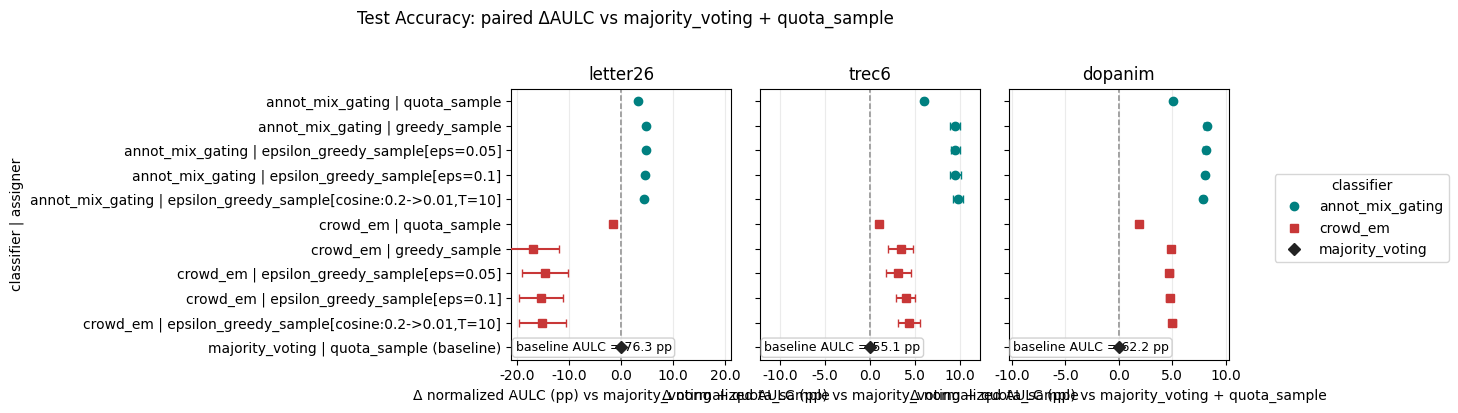

**Main learning curve: letter26**

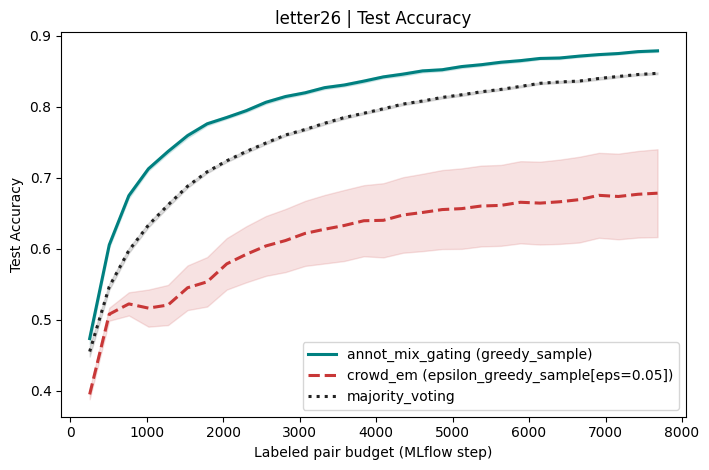

**Main learning curve: trec6**

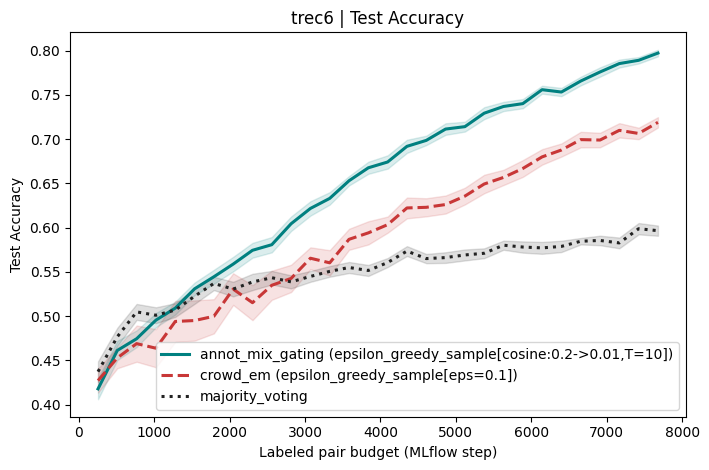

**Main learning curve: dopanim**

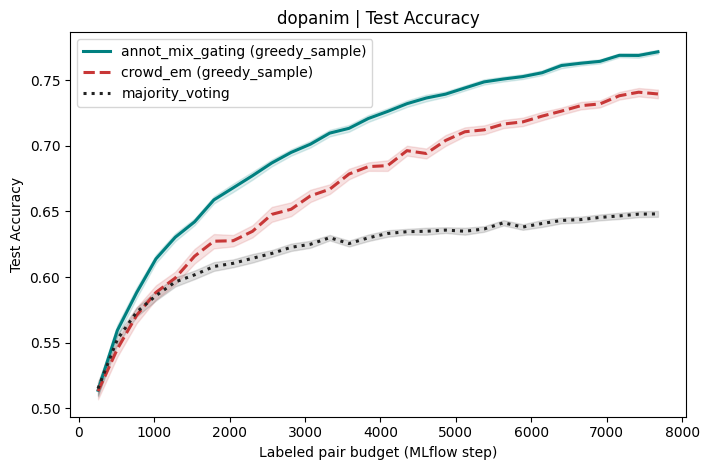

### Pair Accuracy (micro)

Loaded 24750 metric-history rows for metric='acc_pair_micro' from 825 filtered runs.


,dataset,strategy,n_runs,n_seeds,seeds,duplicate_runs
0,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
1,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
2,dopanim,annot_mix_gating | performance + epsilon_greed...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
3,dopanim,annot_mix_gating | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
4,dopanim,annot_mix_gating | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
5,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
6,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
7,dopanim,crowd_em | performance + epsilon_greedy_sample...,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
8,dopanim,crowd_em | performance + greedy_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0
9,dopanim,crowd_em | random + quota_sample,25,25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0


**Selected strategy per dataset and classifier**

,dataset,classifier,selected_assigner,aulc_mean,aulc_se
0,dopanim,annot_mix_gating,greedy_sample,0.717336,0.001613
1,dopanim,crowd_em,greedy_sample,0.715655,0.003210
2,dopanim,majority_voting,quota_sample,0.654724,0.001400
3,letter26,annot_mix_gating,greedy_sample,0.688233,0.003226
4,letter26,crowd_em,epsilon_greedy_sample[eps=0.05],0.517338,0.031760
5,letter26,majority_voting,quota_sample,0.577625,0.001560
6,trec6,annot_mix_gating,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.521518,0.002641
7,trec6,crowd_em,epsilon_greedy_sample[eps=0.1],0.513825,0.009828
8,trec6,majority_voting,quota_sample,0.476412,0.001329


**Paired ΔAULC vs majority_voting + quota_sample**

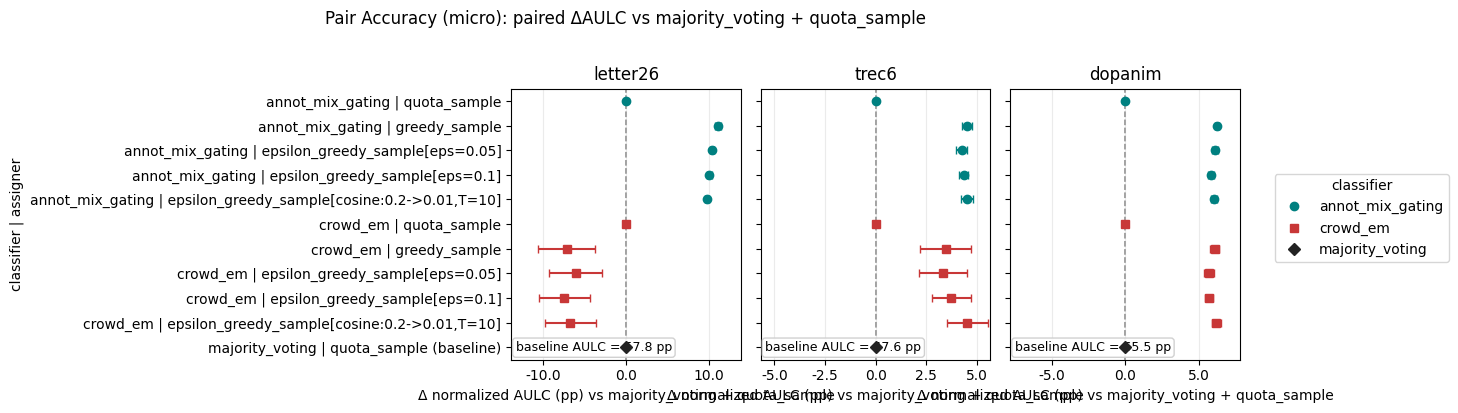

**Main learning curve: letter26**

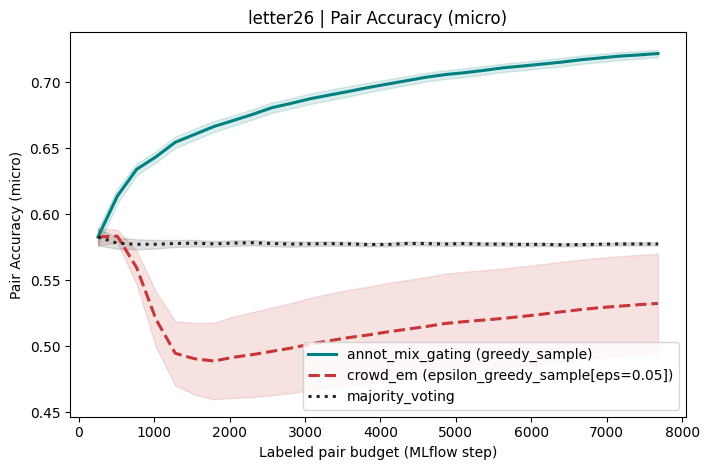

**Main learning curve: trec6**

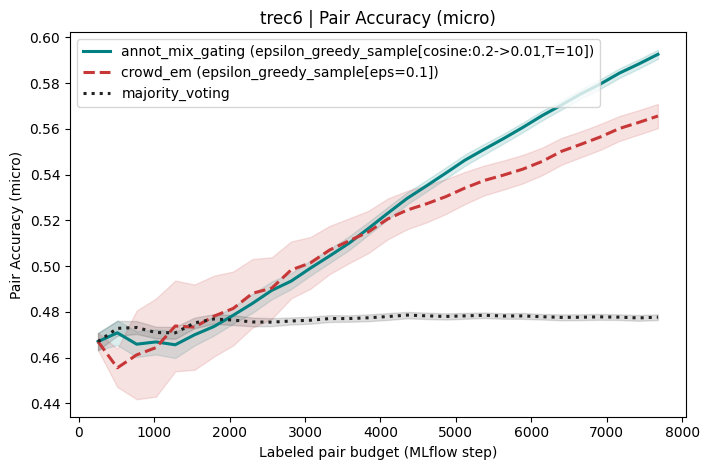

**Main learning curve: dopanim**

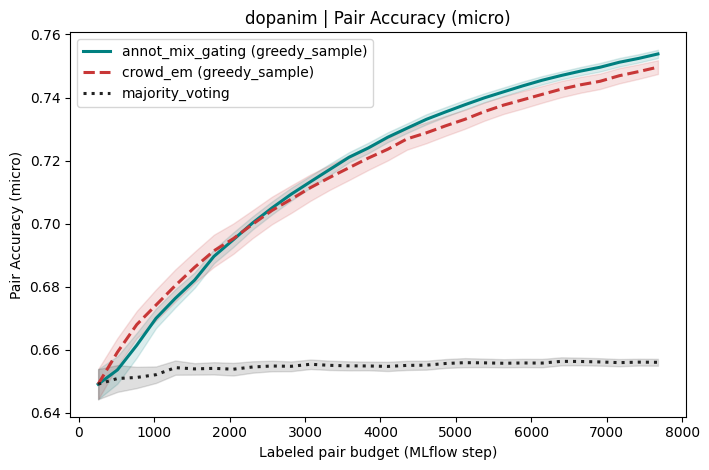

In [6]:
metric_results: dict[str, dict[str, pd.DataFrame]] = {}

for metric_name in METRICS:
    display(Markdown(f"### {metric_label(metric_name)}"))

    # Materialize the per-step trajectories that feed every later summary.
    history_df = load_metric_history_table(
        client,
        filtered_runs_df,
        metric_name,
        only_finished=FILTER_ONLY_FINISHED,
    )
    print(
        f"Loaded {len(history_df)} metric-history rows for metric={metric_name!r} "
        f"from {len(filtered_runs_df)} filtered runs."
    )

    history_run_coverage = summarize_run_coverage(
        history_df[["run_id", "dataset", "seed", "strategy"]].drop_duplicates()
    )
    display(history_run_coverage.head(40))

    # Build the full chain of summaries once so both the main view and
    # appendix can reuse the same intermediate tables.
    aulc_df = compute_aulc_per_run(history_df)
    aulc_summary_df = summarize_aulc(aulc_df)
    delta_aulc_summary_df = summarize_delta_aulc(
        aulc_df,
        metric_name=metric_name,
        baseline_classifier=DELTA_BASELINE_CLASSIFIER,
        baseline_assigner=DELTA_BASELINE_ASSIGNER,
        classifiers=APPENDIX_CLASSIFIERS,
    )
    curve_df = compute_curve_summary(history_df)
    selected_df = select_main_strategies(
        aulc_summary_df,
        classifiers=MAIN_CLASSIFIERS,
        dataset_order=DATASET_ORDER,
    )

    metric_results[metric_name] = {
        "history": history_df,
        "aulc": aulc_df,
        "aulc_summary": aulc_summary_df,
        "delta_aulc_summary": delta_aulc_summary_df,
        "curve": curve_df,
        "selected": selected_df,
    }

    display(Markdown("**Selected strategy per dataset and classifier**"))
    display(format_main_selection_table(selected_df))

    display(Markdown(
        f"**Paired ΔAULC vs {DELTA_BASELINE_CLASSIFIER} + {DELTA_BASELINE_ASSIGNER}**"
    ))
    delta_fig = plot_delta_aulc_dotplot(
        delta_aulc_summary_df,
        metric_name=metric_name,
        classifiers=APPENDIX_CLASSIFIERS,
        dataset_order=DATASET_ORDER,
        baseline_classifier=DELTA_BASELINE_CLASSIFIER,
        baseline_assigner=DELTA_BASELINE_ASSIGNER,
    )
    if delta_fig is not None:
        delta_fig.savefig(OUTPUT_DIR / f"delta_aulc_{metric_name}.pdf", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(delta_fig)

    for dataset in DATASET_ORDER:
        display(Markdown(f"**Main learning curve: {dataset}**"))
        fig = plot_main_learning_curve_panel(
            curve_df,
            selected_df,
            dataset=dataset,
            metric_name=metric_name,
        )
        if fig is not None:
            fig.savefig(OUTPUT_DIR / f"main_learning_curve_{metric_name}_{dataset}.pdf", dpi=300, bbox_inches="tight")
            plt.show()
            plt.close(fig)
        else:
            print(f"No plot available for dataset={dataset!r}.")


## Appendix: Full Assigner Sweeps And Pairwise Diagnostics

The appendix deliberately exposes the detail that the main section hides.

It includes three complementary diagnostics:
- a heatmap of mean normalized AULC values for every classifier-assigner combination
- full learning-curve sweeps for each classifier across all assigners
- pairwise win-rate tables that compare strategies on matched dataset/seed/step cells

These views are useful when a main-paper selection looks surprising and
you want to inspect the trade-offs it is summarizing away.


### Appendix for Test Accuracy

**Raw AULC heatmap**

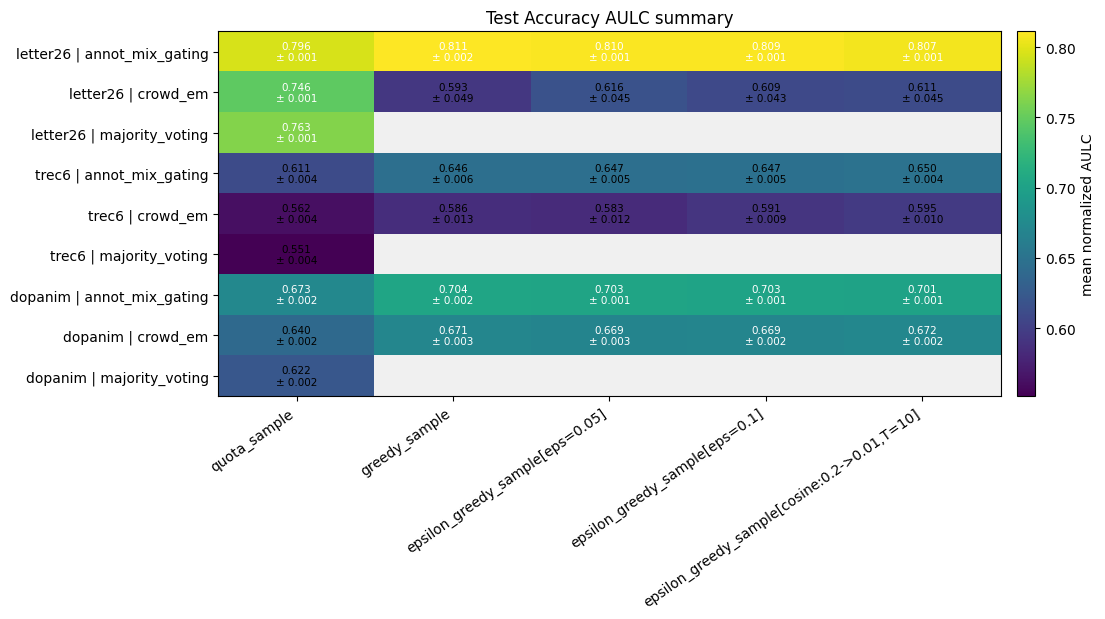

**Full AULC summary**

,dataset,classifier_variant,assigner_variant,aulc_mean,aulc_se,n_runs,n_seeds
0,dopanim,annot_mix_gating,greedy_sample,0.704197,0.001662,25,25
1,dopanim,annot_mix_gating,epsilon_greedy_sample[eps=0.05],0.703262,0.001228,25,25
2,dopanim,annot_mix_gating,epsilon_greedy_sample[eps=0.1],0.702521,0.001307,25,25
3,dopanim,annot_mix_gating,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.700772,0.001352,25,25
4,dopanim,annot_mix_gating,quota_sample,0.672689,0.002018,25,25
5,dopanim,crowd_em,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.671998,0.002413,25,25
6,dopanim,crowd_em,greedy_sample,0.670889,0.002758,25,25
7,dopanim,crowd_em,epsilon_greedy_sample[eps=0.1],0.669364,0.002216,25,25
8,dopanim,crowd_em,epsilon_greedy_sample[eps=0.05],0.669109,0.002599,25,25
9,dopanim,crowd_em,quota_sample,0.640439,0.001619,25,25


**All assigners for annot_mix_gating**

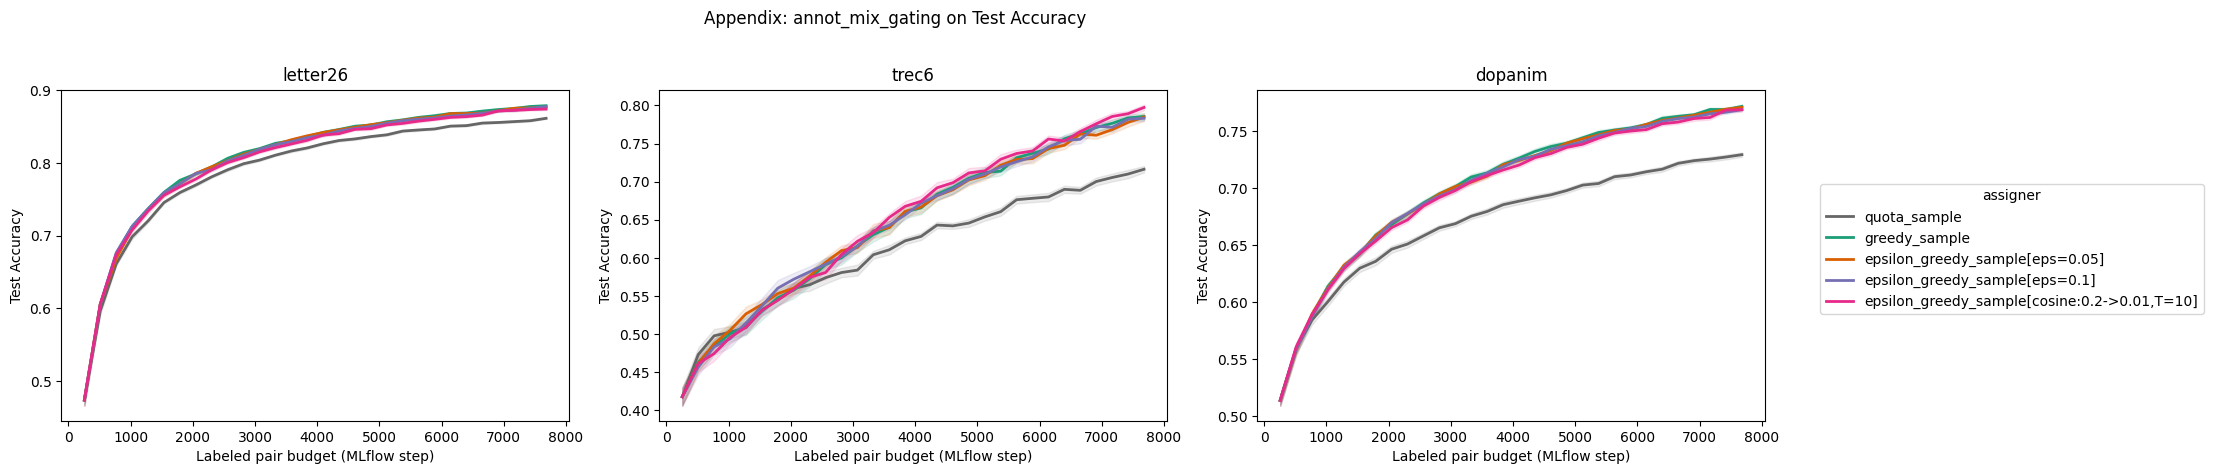

**All assigners for crowd_em**

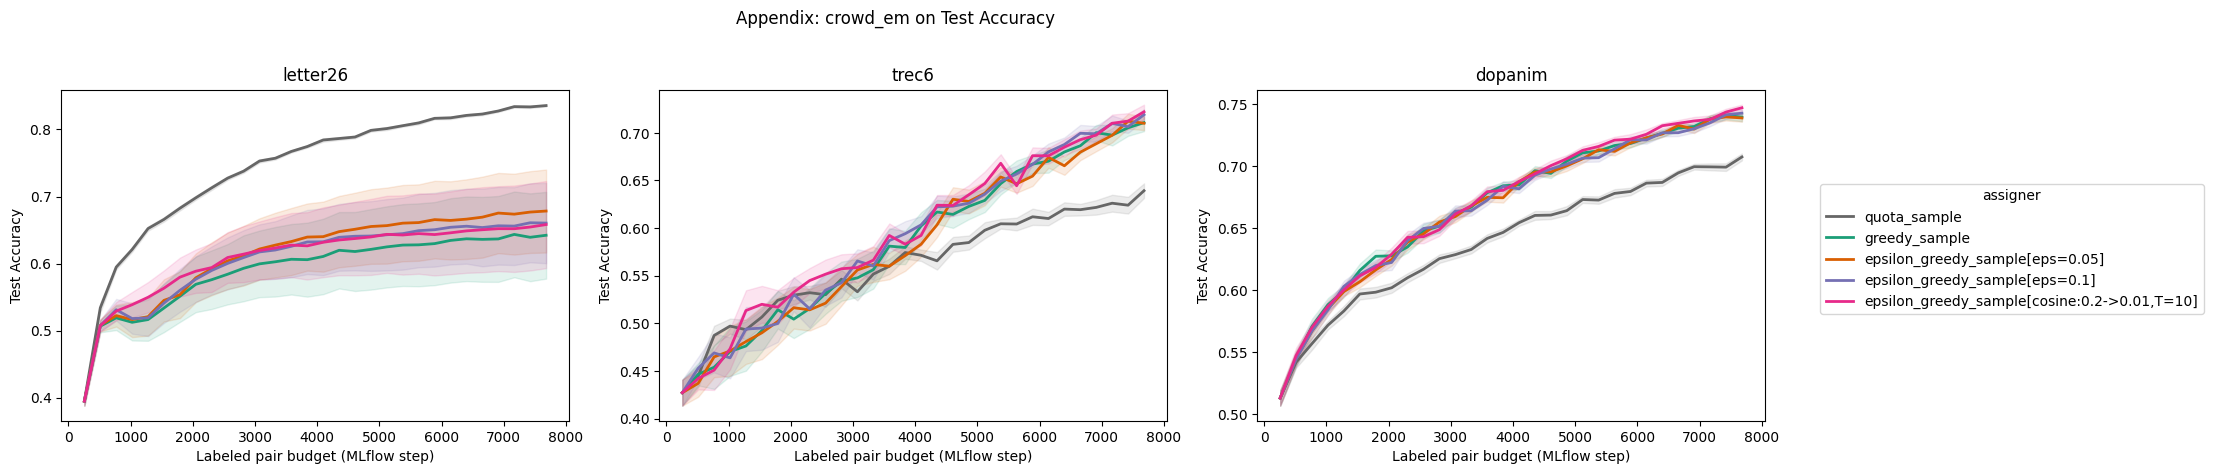

**All assigners for majority_voting**

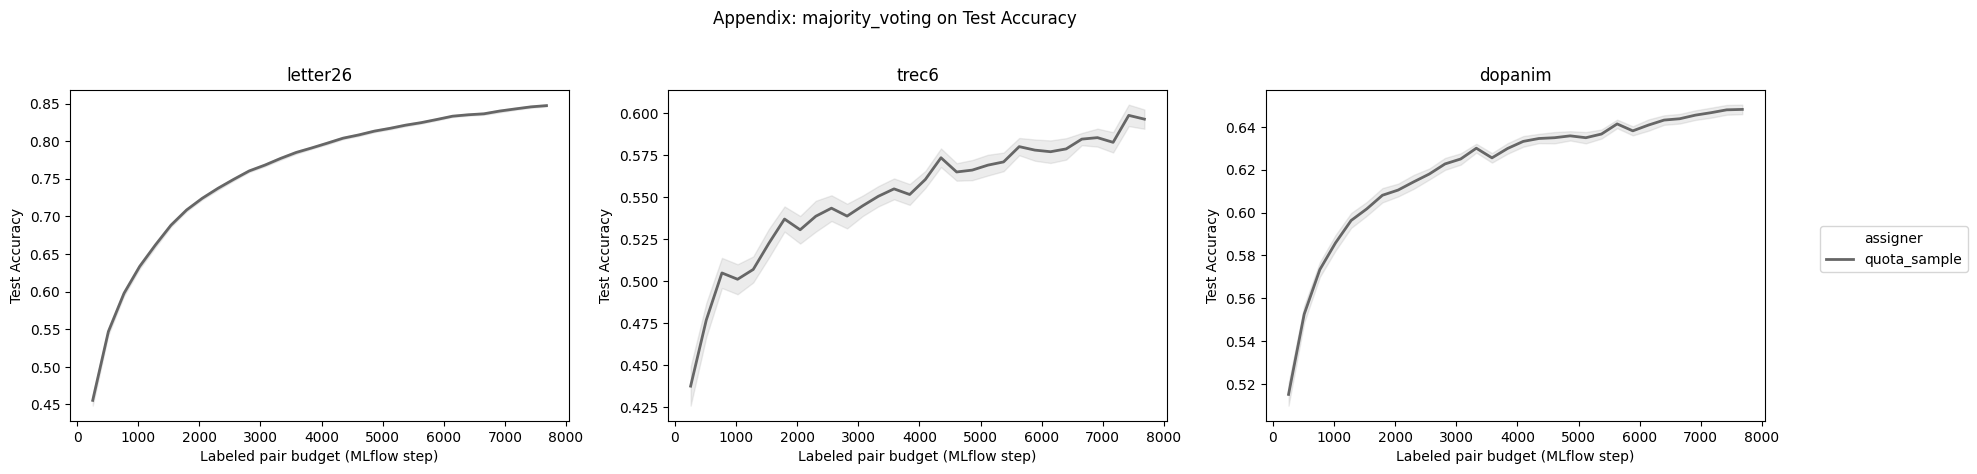

**Pairwise win-rate matrices by dataset**

Dataset=letter26: pairwise rows=110


,strategy_a,strategy_b,n_cells,win_rate_a,tie_rate,loss_rate_a,mean_delta,median_delta
8,annot_mix_gating | performance + epsilon_greed...,crowd_em | random + quota_sample,750,1.000000,0.000000,0.000000,0.060381,0.057250
9,annot_mix_gating | performance + epsilon_greed...,majority_voting | random + quota_sample,750,0.993333,0.000000,0.006667,0.043071,0.040500
6,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.980000,0.000000,0.020000,0.196220,0.086375
4,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.978667,0.000000,0.021333,0.194075,0.078000
5,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.965333,0.001333,0.033333,0.188535,0.083875
7,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + greedy_sample,750,0.962667,0.002667,0.034667,0.211572,0.082875
3,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | random + quota_sample,750,0.830667,0.037333,0.132000,0.011032,0.010750
1,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.364000,0.046667,0.589333,-0.002517,-0.002250
0,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.345333,0.046667,0.608000,-0.003121,-0.003000
2,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + greedy_sample,750,0.282667,0.040000,0.677333,-0.004413,-0.005125


strategy_b,"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],annot_mix_gating | performance + greedy_sample,annot_mix_gating | random + quota_sample,"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",crowd_em | performance + epsilon_greedy_sample[eps=0.05],crowd_em | performance + epsilon_greedy_sample[eps=0.1],crowd_em | performance + greedy_sample,crowd_em | random + quota_sample,majority_voting | random + quota_sample
strategy_a,,,,,,,,,,,
"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",NaN,0.345333,0.364000,0.282667,0.830667,0.978667,0.965333,0.980000,0.962667,1.000000,0.993333
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],0.608000,NaN,0.536000,0.413333,0.890667,0.993333,0.976000,0.990667,0.981333,1.000000,0.993333
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],0.589333,0.421333,NaN,0.398667,0.854667,0.992000,0.973333,0.990667,0.976000,1.000000,0.993333
annot_mix_gating | performance + greedy_sample,0.677333,0.545333,0.560000,NaN,0.866667,0.994667,0.982667,0.990667,0.980000,1.000000,0.992000
annot_mix_gating | random + quota_sample,0.132000,0.074667,0.108000,0.097333,NaN,0.948000,0.934667,0.946667,0.918667,1.000000,0.993333
"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.021333,0.006667,0.006667,0.005333,0.052000,NaN,0.537333,0.513333,0.506667,0.376000,0.192000
crowd_em | performance + epsilon_greedy_sample[eps=0.05],0.033333,0.024000,0.026667,0.017333,0.064000,0.426667,NaN,0.464000,0.597333,0.356000,0.245333
crowd_em | performance + epsilon_greedy_sample[eps=0.1],0.020000,0.008000,0.008000,0.008000,0.053333,0.450667,0.501333,NaN,0.506667,0.310667,0.194667
crowd_em | performance + greedy_sample,0.034667,0.018667,0.022667,0.020000,0.080000,0.457333,0.364000,0.458667,NaN,0.337333,0.240000


Dataset=trec6: pairwise rows=110


...

Dataset=dopanim: pairwise rows=110


,strategy_a,strategy_b,n_cells,win_rate_a,tie_rate,loss_rate_a,mean_delta,median_delta
8,annot_mix_gating | performance + epsilon_greed...,crowd_em | random + quota_sample,750,0.973333,0.001333,0.025333,0.059356,0.061111
9,annot_mix_gating | performance + epsilon_greed...,majority_voting | random + quota_sample,750,0.964000,0.001333,0.034667,0.078290,0.088222
6,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.918667,0.000000,0.081333,0.030808,0.031000
4,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.901333,0.000000,0.098667,0.028188,0.027778
5,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.896000,0.001333,0.102667,0.031119,0.031778
7,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + greedy_sample,750,0.894667,0.002667,0.102667,0.029386,0.029556
3,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | random + quota_sample,750,0.893333,0.033333,0.073333,0.027804,0.028000
1,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.430667,0.036000,0.533333,-0.001691,-0.001111
0,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.382667,0.041333,0.576000,-0.002441,-0.002444
2,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + greedy_sample,750,0.373333,0.041333,0.585333,-0.003360,-0.002444


strategy_b,"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],annot_mix_gating | performance + greedy_sample,annot_mix_gating | random + quota_sample,"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",crowd_em | performance + epsilon_greedy_sample[eps=0.05],crowd_em | performance + epsilon_greedy_sample[eps=0.1],crowd_em | performance + greedy_sample,crowd_em | random + quota_sample,majority_voting | random + quota_sample
strategy_a,,,,,,,,,,,
"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",NaN,0.382667,0.430667,0.373333,0.893333,0.901333,0.896000,0.918667,0.894667,0.973333,0.964000
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],0.576000,NaN,0.520000,0.434667,0.885333,0.918667,0.926667,0.921333,0.922667,0.969333,0.954667
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],0.533333,0.442667,NaN,0.424000,0.890667,0.908000,0.909333,0.930667,0.890667,0.974667,0.962667
annot_mix_gating | performance + greedy_sample,0.585333,0.528000,0.533333,NaN,0.882667,0.912000,0.910667,0.934667,0.901333,0.976000,0.953333
annot_mix_gating | random + quota_sample,0.073333,0.078667,0.074667,0.082667,NaN,0.480000,0.540000,0.517333,0.505333,0.968000,0.962667
"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.098667,0.077333,0.092000,0.088000,0.518667,NaN,0.552000,0.534667,0.509333,0.853333,0.861333
crowd_em | performance + epsilon_greedy_sample[eps=0.05],0.102667,0.072000,0.086667,0.088000,0.458667,0.410667,NaN,0.482667,0.436000,0.849333,0.861333
crowd_em | performance + epsilon_greedy_sample[eps=0.1],0.081333,0.077333,0.066667,0.064000,0.480000,0.429333,0.481333,NaN,0.466667,0.850667,0.868000
crowd_em | performance + greedy_sample,0.102667,0.076000,0.108000,0.097333,0.492000,0.453333,0.525333,0.494667,NaN,0.857333,0.878667


### Appendix for Pair Accuracy (micro)

**Raw AULC heatmap**

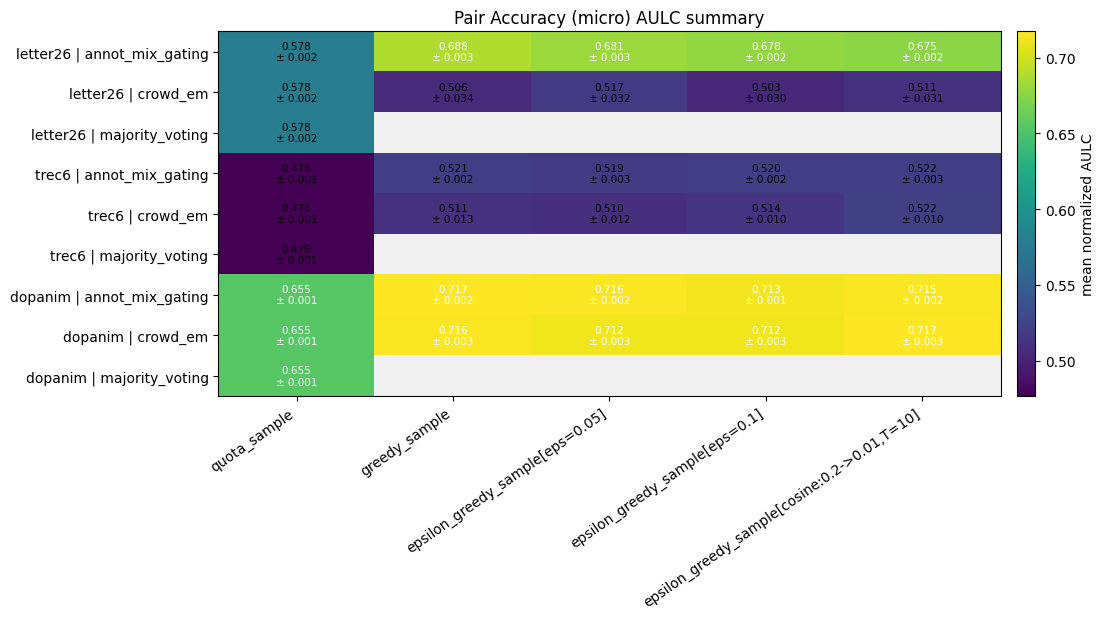

**Full AULC summary**

,dataset,classifier_variant,assigner_variant,aulc_mean,aulc_se,n_runs,n_seeds
0,dopanim,annot_mix_gating,greedy_sample,0.717336,0.001613,25,25
1,dopanim,annot_mix_gating,epsilon_greedy_sample[eps=0.05],0.716132,0.001659,25,25
2,dopanim,annot_mix_gating,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.715479,0.001686,25,25
3,dopanim,annot_mix_gating,epsilon_greedy_sample[eps=0.1],0.713195,0.001358,25,25
4,dopanim,annot_mix_gating,quota_sample,0.654724,0.001400,25,25
5,dopanim,crowd_em,"epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.716669,0.002822,25,25
6,dopanim,crowd_em,greedy_sample,0.715655,0.003210,25,25
7,dopanim,crowd_em,epsilon_greedy_sample[eps=0.05],0.711826,0.002857,25,25
8,dopanim,crowd_em,epsilon_greedy_sample[eps=0.1],0.711767,0.002819,25,25
9,dopanim,crowd_em,quota_sample,0.654724,0.001400,25,25


**All assigners for annot_mix_gating**

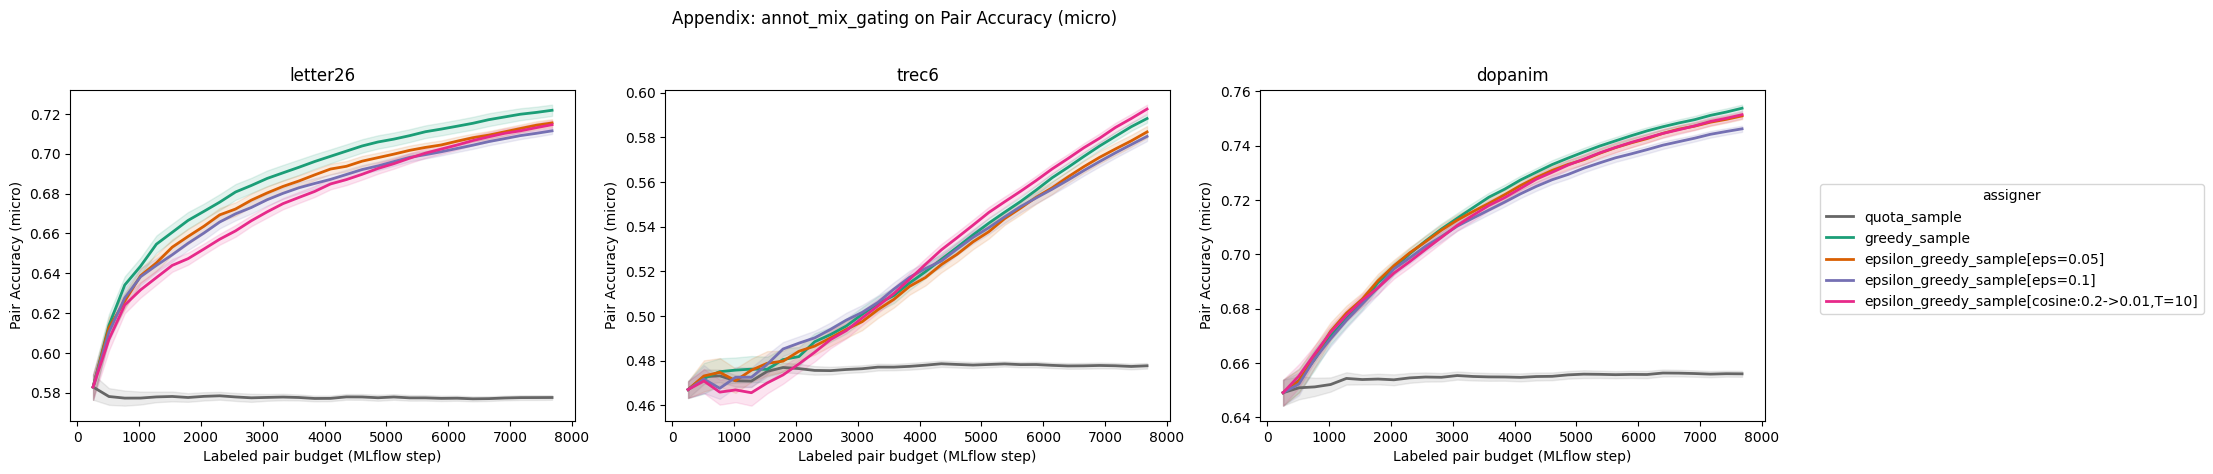

**All assigners for crowd_em**

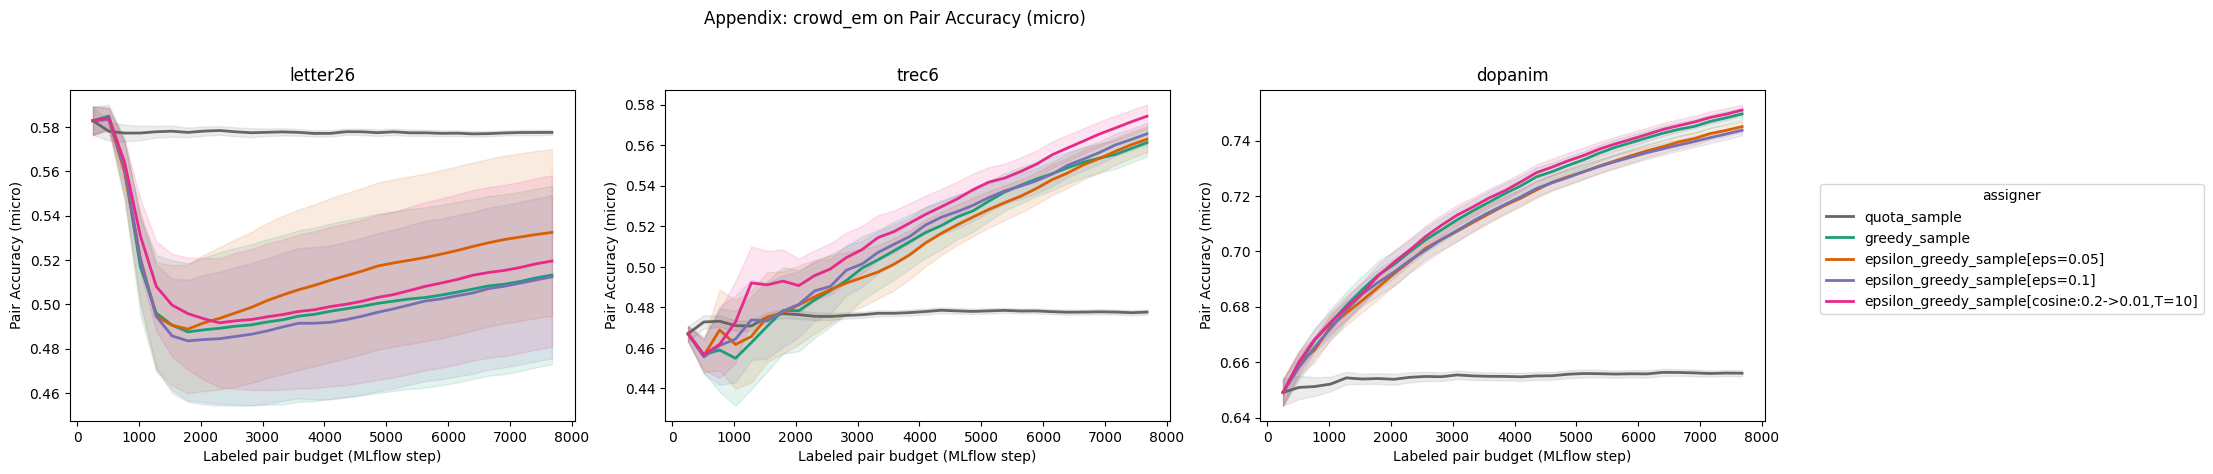

**All assigners for majority_voting**

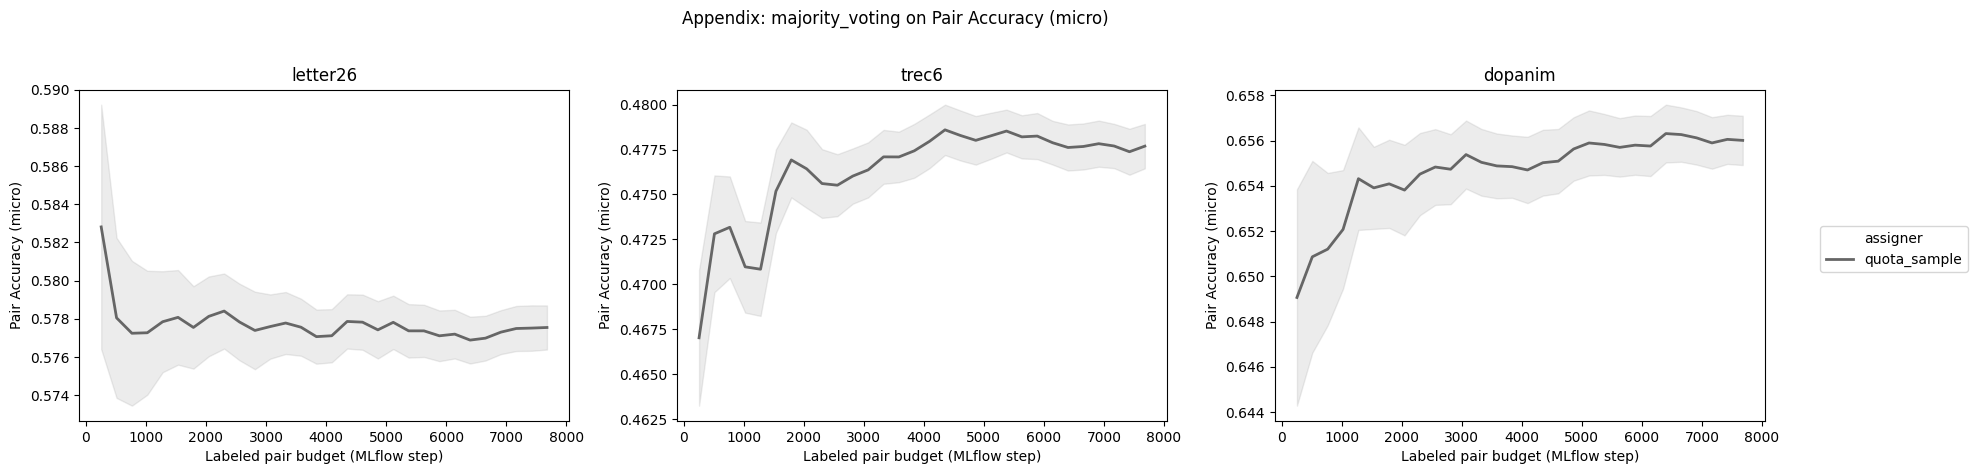

**Pairwise win-rate matrices by dataset**

Dataset=letter26: pairwise rows=110


,strategy_a,strategy_b,n_cells,win_rate_a,tie_rate,loss_rate_a,mean_delta,median_delta
3,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | random + quota_sample,750,0.965333,0.033333,0.001333,0.096753,0.103380
8,annot_mix_gating | performance + epsilon_greed...,crowd_em | random + quota_sample,750,0.965333,0.033333,0.001333,0.096753,0.103380
9,annot_mix_gating | performance + epsilon_greed...,majority_voting | random + quota_sample,750,0.965333,0.033333,0.001333,0.096753,0.103380
4,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.910667,0.033333,0.056000,0.162482,0.091872
6,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.884000,0.037333,0.078667,0.169574,0.110910
5,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.857333,0.033333,0.109333,0.155783,0.086388
7,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + greedy_sample,750,0.840000,0.034667,0.125333,0.167038,0.093544
1,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.386667,0.045333,0.568000,-0.002515,-0.001302
0,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.345333,0.044000,0.610667,-0.005681,-0.005268
2,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + greedy_sample,750,0.152000,0.040000,0.808000,-0.012572,-0.011909


strategy_b,"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],annot_mix_gating | performance + greedy_sample,annot_mix_gating | random + quota_sample,"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",crowd_em | performance + epsilon_greedy_sample[eps=0.05],crowd_em | performance + epsilon_greedy_sample[eps=0.1],crowd_em | performance + greedy_sample,crowd_em | random + quota_sample,majority_voting | random + quota_sample
strategy_a,,,,,,,,,,,
"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",NaN,0.345333,0.386667,0.152000,0.965333,0.910667,0.857333,0.884000,0.840000,0.965333,0.965333
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],0.610667,NaN,0.604000,0.230667,0.961333,0.948000,0.880000,0.926667,0.858667,0.961333,0.961333
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],0.568000,0.344000,NaN,0.228000,0.962667,0.934667,0.872000,0.917333,0.846667,0.962667,0.962667
annot_mix_gating | performance + greedy_sample,0.808000,0.724000,0.728000,NaN,0.962667,0.944000,0.888000,0.909333,0.866667,0.962667,0.962667
annot_mix_gating | random + quota_sample,0.001333,0.002667,0.002667,0.004000,NaN,0.478667,0.490667,0.548000,0.464000,0.000000,0.000000
"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.056000,0.018667,0.032000,0.020000,0.486667,NaN,0.516000,0.454667,0.456000,0.486667,0.486667
crowd_em | performance + epsilon_greedy_sample[eps=0.05],0.109333,0.084000,0.093333,0.078667,0.472000,0.437333,NaN,0.514667,0.541333,0.472000,0.472000
crowd_em | performance + epsilon_greedy_sample[eps=0.1],0.078667,0.040000,0.046667,0.053333,0.417333,0.505333,0.437333,NaN,0.417333,0.417333,0.417333
crowd_em | performance + greedy_sample,0.125333,0.105333,0.117333,0.100000,0.501333,0.504000,0.414667,0.544000,NaN,0.501333,0.501333


Dataset=trec6: pairwise rows=110


,strategy_a,strategy_b,n_cells,win_rate_a,tie_rate,loss_rate_a,mean_delta,median_delta
3,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | random + quota_sample,750,0.800000,0.041333,0.158667,0.045518,0.045119
8,annot_mix_gating | performance + epsilon_greed...,crowd_em | random + quota_sample,750,0.800000,0.041333,0.158667,0.045518,0.045119
9,annot_mix_gating | performance + epsilon_greed...,majority_voting | random + quota_sample,750,0.800000,0.041333,0.158667,0.045518,0.045119
5,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.616000,0.034667,0.349333,0.011821,0.015904
6,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.610667,0.034667,0.354667,0.007886,0.014550
7,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + greedy_sample,750,0.592000,0.033333,0.374667,0.010671,0.013341
0,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.545333,0.042667,0.412000,0.002708,0.001953
1,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.537333,0.040000,0.422667,0.001774,0.002163
2,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + greedy_sample,750,0.526667,0.041333,0.432000,0.000217,0.001473
4,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.466667,0.034667,0.498667,0.000038,0.000000


strategy_b,"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],annot_mix_gating | performance + greedy_sample,annot_mix_gating | random + quota_sample,"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",crowd_em | performance + epsilon_greedy_sample[eps=0.05],crowd_em | performance + epsilon_greedy_sample[eps=0.1],crowd_em | performance + greedy_sample,crowd_em | random + quota_sample,majority_voting | random + quota_sample
strategy_a,,,,,,,,,,,
"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",NaN,0.545333,0.537333,0.526667,0.800000,0.466667,0.616000,0.610667,0.592000,0.800000,0.800000
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],0.412000,NaN,0.488000,0.382667,0.830667,0.401333,0.570667,0.565333,0.600000,0.830667,0.830667
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],0.422667,0.469333,NaN,0.384000,0.834667,0.477333,0.561333,0.613333,0.541333,0.834667,0.834667
annot_mix_gating | performance + greedy_sample,0.432000,0.577333,0.570667,NaN,0.838667,0.514667,0.602667,0.585333,0.590667,0.838667,0.838667
annot_mix_gating | random + quota_sample,0.158667,0.133333,0.126667,0.126667,NaN,0.202667,0.258667,0.222667,0.245333,0.000000,0.000000
"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.498667,0.558667,0.488000,0.450667,0.764000,NaN,0.570667,0.501333,0.505333,0.764000,0.764000
crowd_em | performance + epsilon_greedy_sample[eps=0.05],0.349333,0.396000,0.401333,0.362667,0.708000,0.393333,NaN,0.346667,0.326667,0.708000,0.708000
crowd_em | performance + epsilon_greedy_sample[eps=0.1],0.354667,0.398667,0.353333,0.378667,0.740000,0.458667,0.614667,NaN,0.506667,0.740000,0.740000
crowd_em | performance + greedy_sample,0.374667,0.366667,0.421333,0.374667,0.720000,0.458667,0.629333,0.453333,NaN,0.720000,0.720000


Dataset=dopanim: pairwise rows=110


,strategy_a,strategy_b,n_cells,win_rate_a,tie_rate,loss_rate_a,mean_delta,median_delta
3,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | random + quota_sample,750,0.937333,0.033333,0.029333,0.060321,0.067023
8,annot_mix_gating | performance + epsilon_greed...,crowd_em | random + quota_sample,750,0.937333,0.033333,0.029333,0.060321,0.067023
9,annot_mix_gating | performance + epsilon_greed...,majority_voting | random + quota_sample,750,0.937333,0.033333,0.029333,0.060321,0.067023
6,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.592000,0.036000,0.372000,0.003716,0.004102
5,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.562667,0.040000,0.397333,0.003638,0.003809
1,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.549333,0.046667,0.404000,0.002295,0.001636
7,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + greedy_sample,750,0.493333,0.041333,0.465333,-0.000140,0.000000
4,annot_mix_gating | performance + epsilon_greed...,crowd_em | performance + epsilon_greedy_sample...,750,0.446667,0.041333,0.512000,-0.001142,-0.000825
0,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + epsilon_greed...,750,0.418667,0.036000,0.545333,-0.000623,-0.001302
2,annot_mix_gating | performance + epsilon_greed...,annot_mix_gating | performance + greedy_sample,750,0.393333,0.042667,0.564000,-0.001834,-0.002023


strategy_b,"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],annot_mix_gating | performance + greedy_sample,annot_mix_gating | random + quota_sample,"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",crowd_em | performance + epsilon_greedy_sample[eps=0.05],crowd_em | performance + epsilon_greedy_sample[eps=0.1],crowd_em | performance + greedy_sample,crowd_em | random + quota_sample,majority_voting | random + quota_sample
strategy_a,,,,,,,,,,,
"annot_mix_gating | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",NaN,0.418667,0.549333,0.393333,0.937333,0.446667,0.562667,0.592000,0.493333,0.937333,0.937333
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.05],0.545333,NaN,0.592000,0.429333,0.930667,0.473333,0.562667,0.600000,0.485333,0.930667,0.930667
annot_mix_gating | performance + epsilon_greedy_sample[eps=0.1],0.404000,0.356000,NaN,0.329333,0.921333,0.426667,0.449333,0.529333,0.372000,0.921333,0.921333
annot_mix_gating | performance + greedy_sample,0.564000,0.521333,0.618667,NaN,0.922667,0.506667,0.573333,0.605333,0.537333,0.922667,0.922667
annot_mix_gating | random + quota_sample,0.029333,0.032000,0.037333,0.038667,NaN,0.038667,0.046667,0.042667,0.050667,0.000000,0.000000
"crowd_em | performance + epsilon_greedy_sample[cosine:0.2->0.01,T=10]",0.512000,0.477333,0.534667,0.456000,0.928000,NaN,0.660000,0.636000,0.501333,0.928000,0.928000
crowd_em | performance + epsilon_greedy_sample[eps=0.05],0.397333,0.398667,0.506667,0.390667,0.920000,0.301333,NaN,0.533333,0.313333,0.920000,0.920000
crowd_em | performance + epsilon_greedy_sample[eps=0.1],0.372000,0.358667,0.429333,0.356000,0.922667,0.321333,0.421333,NaN,0.302667,0.922667,0.922667
crowd_em | performance + greedy_sample,0.465333,0.478667,0.590667,0.424000,0.916000,0.454667,0.630667,0.638667,NaN,0.916000,0.916000


In [7]:
for metric_name in METRICS:
    display(Markdown(f"### Appendix for {metric_label(metric_name)}"))
    history_df = metric_results[metric_name]["history"]
    curve_df = metric_results[metric_name]["curve"]
    aulc_summary_df = metric_results[metric_name]["aulc_summary"]

    display(Markdown("**Raw AULC heatmap**"))
    heatmap_fig = plot_aulc_heatmap(
        aulc_summary_df,
        metric_name=metric_name,
        classifiers=APPENDIX_CLASSIFIERS,
        dataset_order=DATASET_ORDER,
    )
    if heatmap_fig is not None:
        plt.show()
        plt.close(heatmap_fig)

    display(Markdown("**Full AULC summary**"))
    appendix_table = aulc_summary_df[[
        "dataset", "classifier_variant", "assigner_variant", "aulc_mean", "aulc_se", "n_runs", "n_seeds"
    ]].sort_values(["dataset", "classifier_variant", "aulc_mean"], ascending=[True, True, False])
    display(appendix_table)

    # Show how each classifier behaves across the full assigner sweep.
    for classifier in APPENDIX_CLASSIFIERS:
        display(Markdown(f"**All assigners for {classifier}**"))
        fig = plot_appendix_learning_curves(
            curve_df,
            classifier_variant=classifier,
            metric_name=metric_name,
            dataset_order=DATASET_ORDER,
        )
        if fig is not None:
            plt.show()
            plt.close(fig)
        else:
            print(f"No appendix plot available for classifier={classifier!r}.")

    display(Markdown("**Pairwise win-rate matrices by dataset**"))
    for dataset in DATASET_ORDER:
        dataset_history_df = history_df[history_df["dataset"] == dataset].copy()
        pairwise_df = pairwise_win_rates(dataset_history_df)
        print(f"Dataset={dataset}: pairwise rows={len(pairwise_df)}")
        if pairwise_df.empty:
            print("No pairwise comparisons available.")
            continue
        display(pairwise_df.head(20))
        win_matrix = pairwise_win_matrix(pairwise_df)
        display(win_matrix)
